In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, time, sqlite3
import pandas as pd
import numpy as np

PROJECT_ROOT = '/content/drive/MyDrive/Equity'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
DB_PATH = os.path.join(DATA_DIR, 'equity_market.db')

max_wait = 30
waited = 0
while not os.path.exists(DB_PATH) and waited < max_wait:
    time.sleep(2)
    waited += 2
    print(f"Waiting for Drive to sync... ({waited}s)")

if not os.path.exists(DB_PATH):
    raise RuntimeError("DB_PATH not found.")

size_mb = os.path.getsize(DB_PATH) / (1024 * 1024)

print(f"Database verified: {size_mb:.2f} MB.")

conn = sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True)


checkpoint = pd.read_sql("""
    SELECT
        (SELECT COUNT(*) FROM daily_prices) AS total_price_rows,
        (SELECT COUNT(DISTINCT ticker) FROM daily_prices) AS distinct_tickers,
        (SELECT COUNT(*) FROM stock_metadata) AS metadata_rows
""", conn)
print(checkpoint)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Database verified: 145.80 MB.
   total_price_rows  distinct_tickers  metadata_rows
0           1011944               456            455


In [ ]:
CHARTS_DIR = os.path.join(PROJECT_ROOT, 'charts')
os.makedirs(CHARTS_DIR, exist_ok=True)
print(f'Charts will be saved to: {CHARTS_DIR}')

In [ ]:
import pandas as pd

try:
    pd.read_sql("CREATE TABLE test_write_check (x INTEGER)", conn)
    print("WARNING: write succeeded — read-only protection is NOT working")
except Exception as e:
    print(f"Confirmed read-only: {type(e).__name__}")

Confirmed read-only: DatabaseError


In [ ]:
KNOWN_DATA_ARTIFACTS = {
    ("ABREL", "2019-10-11"), ("CDSL", "2017-07-03"), ("CGCL", "2024-01-01"),
    ("GPIL", "2024-01-01"), ("J&KBANK", "2017-02-27"), ("JSL", "2015-11-19"),
    ("MOTILALOFS", "2024-01-01"), ("PATANJALI", "2020-01-27"),
    ("INDIAMART", "2019-10-27"), ("INDIAMART", "2019-10-29"),
    ("INDIAMART", "2020-11-14"), ("INDIAMART", "2020-11-17"),
}

raw = pd.read_sql("SELECT ticker, date, open, high, low, close, adj_close, volume FROM daily_prices ORDER BY ticker, date", conn)
raw["date"] = pd.to_datetime(raw["date"])
raw["date_str"] = raw["date"].dt.strftime("%Y-%m-%d")
raw["is_artifact"] = raw.apply(lambda r: (r["ticker"], r["date_str"]) in KNOWN_DATA_ARTIFACTS, axis=1)

df_clean = raw[~raw["is_artifact"]].drop(columns=["date_str", "is_artifact"]).copy()
print(f"df_clean: {len(df_clean)} rows, {df_clean['ticker'].nunique()} tickers")

df_clean: 1011932 rows, 456 tickers


In [ ]:
df_clean = df_clean.sort_values(["ticker", "date"]).reset_index(drop=True)

df_clean["ret_1m"] = df_clean.groupby("ticker")["adj_close"].pct_change(21)
df_clean["ret_3m"] = df_clean.groupby("ticker")["adj_close"].pct_change(63)
df_clean["ret_6m"] = df_clean.groupby("ticker")["adj_close"].pct_change(126)
df_clean["ret_12m"] = df_clean.groupby("ticker")["adj_close"].pct_change(252)

df_clean[["ticker", "date", "adj_close", "ret_1m", "ret_3m", "ret_6m", "ret_12m"]].tail(10)

,ticker,date,adj_close,ret_1m,ret_3m,ret_6m,ret_12m
1011922,ZYDUSWELL,2024-12-16,407.701538,0.094422,-0.074234,0.100463,0.322316
1011923,ZYDUSWELL,2024-12-17,396.963593,0.015378,-0.098882,0.078720,0.275067
1011924,ZYDUSWELL,2024-12-18,396.275665,0.036077,-0.084172,0.079008,0.278576
1011925,ZYDUSWELL,2024-12-19,392.965576,0.013552,-0.079865,0.076791,0.272306
1011926,ZYDUSWELL,2024-12-20,381.130920,-0.010970,-0.076531,0.014875,0.244530
1011927,ZYDUSWELL,2024-12-23,378.349243,-0.009889,-0.088073,0.024398,0.242672
1011928,ZYDUSWELL,2024-12-24,380.801910,-0.002377,-0.082007,0.025927,0.217863
1011929,ZYDUSWELL,2024-12-26,378.797882,-0.016694,-0.062549,0.032313,0.207957
1011930,ZYDUSWELL,2024-12-27,378.578552,-0.044178,-0.045283,0.052457,0.186816
1011931,ZYDUSWELL,2024-12-30,378.189728,-0.058572,-0.043039,0.059402,0.178541


In [ ]:
df_clean["log_return"] = np.log(df_clean["adj_close"] / df_clean.groupby("ticker")["adj_close"].shift(1))

df_clean["vol_21d"] = df_clean.groupby("ticker")["log_return"].transform(lambda x: x.rolling(21).std()) * np.sqrt(252) * 100
df_clean["vol_63d"] = df_clean.groupby("ticker")["log_return"].transform(lambda x: x.rolling(63).std()) * np.sqrt(252) * 100

df_clean[["ticker", "date", "vol_21d", "vol_63d"]].tail(10)

,ticker,date,vol_21d,vol_63d
1011922,ZYDUSWELL,2024-12-16,27.678711,29.283145
1011923,ZYDUSWELL,2024-12-17,24.691713,29.720348
1011924,ZYDUSWELL,2024-12-18,23.311034,29.535845
1011925,ZYDUSWELL,2024-12-19,23.139568,29.475234
1011926,ZYDUSWELL,2024-12-20,25.474456,29.319761
1011927,ZYDUSWELL,2024-12-23,25.434574,29.314055
1011928,ZYDUSWELL,2024-12-24,25.545753,29.355921
1011929,ZYDUSWELL,2024-12-26,25.373474,28.929635
1011930,ZYDUSWELL,2024-12-27,23.154735,28.702476
1011931,ZYDUSWELL,2024-12-30,22.393029,28.697542


In [ ]:
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(period).mean()
    loss = (-delta.clip(upper=0)).rolling(period).mean()
    rs = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))

df_clean["RSI_14"] = df_clean.groupby("ticker")["adj_close"].transform(lambda x: compute_rsi(x))

def compute_macd(series, fast=12, slow=26):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    return ema_fast - ema_slow

df_clean["MACD"] = df_clean.groupby("ticker")["adj_close"].transform(lambda x: compute_macd(x))

def compute_bb_position(series, period=20, num_std=2):
    rolling_mean = series.rolling(period).mean()
    rolling_std = series.rolling(period).std()
    upper_band = rolling_mean + num_std * rolling_std
    lower_band = rolling_mean - num_std * rolling_std
    return (series - lower_band) / (upper_band - lower_band + 1e-9)

df_clean["BB_position"] = df_clean.groupby("ticker")["adj_close"].transform(lambda x: compute_bb_position(x))

df_clean[["ticker", "date", "RSI_14", "MACD", "BB_position"]].tail(10)

,ticker,date,RSI_14,MACD,BB_position
1011922,ZYDUSWELL,2024-12-16,64.670667,4.875479,0.656780
1011923,ZYDUSWELL,2024-12-17,50.580094,3.881004,0.410828
1011924,ZYDUSWELL,2024-12-18,46.194573,3.002751,0.381935
1011925,ZYDUSWELL,2024-12-19,42.567482,2.016390,0.287418
1011926,ZYDUSWELL,2024-12-20,31.512617,0.276545,0.007535
1011927,ZYDUSWELL,2024-12-23,29.600601,-1.311632,-0.036543
1011928,ZYDUSWELL,2024-12-24,25.009949,-2.345329,0.041837
1011929,ZYDUSWELL,2024-12-26,27.198036,-3.288344,0.057627
1011930,ZYDUSWELL,2024-12-27,27.910087,-4.007195,0.106739
1011931,ZYDUSWELL,2024-12-30,29.535143,-4.555749,0.144241


In [ ]:
df_clean["vol_avg_20d"] = df_clean.groupby("ticker")["volume"].transform(lambda x: x.rolling(20).mean())
df_clean["vol_ratio"] = df_clean["volume"] / (df_clean["vol_avg_20d"] + 1e-9)

df_clean[["ticker", "date", "volume", "vol_avg_20d", "vol_ratio"]].tail(10)

,ticker,date,volume,vol_avg_20d,vol_ratio
1011922,ZYDUSWELL,2024-12-16,124040,197882.25,0.626837
1011923,ZYDUSWELL,2024-12-17,536315,215246.00,2.491637
1011924,ZYDUSWELL,2024-12-18,55645,213433.75,0.260713
1011925,ZYDUSWELL,2024-12-19,82795,211662.75,0.391165
1011926,ZYDUSWELL,2024-12-20,165560,217256.75,0.762048
1011927,ZYDUSWELL,2024-12-23,65685,199199.75,0.329744
1011928,ZYDUSWELL,2024-12-24,40220,198224.75,0.202901
1011929,ZYDUSWELL,2024-12-26,96780,182985.00,0.528896
1011930,ZYDUSWELL,2024-12-27,539555,203103.50,2.656552
1011931,ZYDUSWELL,2024-12-30,105510,186894.00,0.564545


In [ ]:
vix_data = pd.read_sql("SELECT date, vix_close FROM india_vix", conn)
vix_data["date"] = pd.to_datetime(vix_data["date"])

nifty_data = df_clean[df_clean["ticker"] == "NIFTY_50"][["date", "ret_1m"]].rename(columns={"ret_1m": "nifty_ret_1m"})

df_clean = df_clean.merge(vix_data, on="date", how="left")
df_clean = df_clean.merge(nifty_data, on="date", how="left")

df_clean[["ticker", "date", "vix_close", "nifty_ret_1m"]].tail(5)

,ticker,date,vix_close,nifty_ret_1m
1011927,ZYDUSWELL,2024-12-23,13.52,-0.006433
1011928,ZYDUSWELL,2024-12-24,13.18,-0.020405
1011929,ZYDUSWELL,2024-12-26,14.04,-0.018364
1011930,ZYDUSWELL,2024-12-27,13.24,-0.019011
1011931,ZYDUSWELL,2024-12-30,13.97,-0.011259


In [ ]:
sector_lookup = pd.read_sql("SELECT ticker, sector FROM stock_metadata", conn)
df_clean = df_clean.merge(sector_lookup, on="ticker", how="left")

sector_dummies = pd.get_dummies(df_clean["sector"], prefix="sector")
df_clean = pd.concat([df_clean, sector_dummies], axis=1)

print(f"Added {sector_dummies.shape[1]} sector dummy columns")
df_clean[[c for c in df_clean.columns if c.startswith("sector_")]].sum().sort_values(ascending=False)

Added 20 sector dummy columns


,0
sector_Financial Services,182820
sector_Capital Goods,127910
sector_Healthcare,90935
sector_Automobile and Auto Components,80727
sector_Fast Moving Consumer Goods,63524
sector_Chemicals,60063
sector_Information Technology,51116
sector_Oil Gas & Consumable Fuels,41555
sector_Metals & Mining,41463
sector_Power,39164


In [ ]:
df_clean["target_direction"] = (
    df_clean.groupby("ticker")["adj_close"].pct_change(21).shift(-21) > 0
).astype(int)

df_clean["target_vol"] = (
    df_clean.groupby("ticker")["log_return"].transform(lambda x: x.rolling(21).std().shift(-21))
) * np.sqrt(252) * 100

print("Target direction distribution:")
print(df_clean["target_direction"].value_counts(normalize=True))
print("\nTarget vol summary:")
print(df_clean["target_vol"].describe())

Target direction distribution:
target_direction
1    0.556442
0    0.443558
Name: proportion, dtype: float64

Target vol summary:
count    1.002356e+06
mean     3.604688e+01
std      1.811040e+01
min      0.000000e+00
25%      2.452889e+01
50%      3.240293e+01
75%      4.322753e+01
max      1.036032e+03
Name: target_vol, dtype: float64


In [ ]:
extreme_vol_targets = df_clean[df_clean["target_vol"] > 300][["ticker", "date", "target_vol"]].sort_values("target_vol", ascending=False)
print(f"Rows with target_vol > 300%: {len(extreme_vol_targets)}")
extreme_vol_targets.head(15)

Rows with target_vol > 300%: 126


,ticker,date,target_vol
727996,PATANJALI,2020-01-24,1036.031875
727995,PATANJALI,2020-01-23,1035.384654
727994,PATANJALI,2020-01-22,1034.715347
727993,PATANJALI,2020-01-21,1034.041899
727992,PATANJALI,2020-01-20,1033.349745
727991,PATANJALI,2020-01-17,1032.639998
727990,PATANJALI,2020-01-16,1031.914120
727989,PATANJALI,2020-01-15,1031.173960
727988,PATANJALI,2020-01-14,1030.421822
727987,PATANJALI,2020-01-13,1029.660486


In [ ]:
artifact_tickers_only = {t for t, d in KNOWN_DATA_ARTIFACTS}
extreme_vol_targets["ticker_was_known_artifact"] = extreme_vol_targets["ticker"].isin(artifact_tickers_only)
extreme_vol_targets["ticker_was_known_artifact"].value_counts()

,count
ticker_was_known_artifact,
True,105
False,21


In [ ]:
ARTIFACT_BUFFER_DAYS = 25

artifact_dates_by_ticker = {}
for ticker, date_str in KNOWN_DATA_ARTIFACTS:
    artifact_dates_by_ticker.setdefault(ticker, []).append(pd.Timestamp(date_str))

def is_near_artifact(row):
    ticker_dates = artifact_dates_by_ticker.get(row["ticker"])
    if not ticker_dates:
        return False
    return any(abs((row["date"] - d).days) <= ARTIFACT_BUFFER_DAYS for d in ticker_dates)

affected_tickers = list(artifact_dates_by_ticker.keys())
mask_check = df_clean["ticker"].isin(affected_tickers)
df_clean.loc[mask_check, "near_artifact"] = df_clean[mask_check].apply(is_near_artifact, axis=1)
df_clean["near_artifact"] = df_clean["near_artifact"].fillna(False)

print(f"Rows flagged as near a known artifact (within {ARTIFACT_BUFFER_DAYS} days): {df_clean['near_artifact'].sum()}")

Rows flagged as near a known artifact (within 25 days): 321


/tmp/ipykernel_913/1642889363.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean["near_artifact"] = df_clean["near_artifact"].fillna(False)


In [ ]:
df_clean.loc[df_clean["near_artifact"], "target_vol"] = np.nan
df_clean.loc[df_clean["near_artifact"], "target_direction"] = np.nan

extreme_check_after = df_clean[df_clean["target_vol"] > 300]
print(f"Rows with target_vol > 300% after fix: {len(extreme_check_after)}")

Rows with target_vol > 300% after fix: 45


In [ ]:
df_clean["near_artifact"] = df_clean["near_artifact"].astype(object)
df_clean.loc[mask_check, "near_artifact"] = df_clean[mask_check].apply(is_near_artifact, axis=1)
df_clean["near_artifact"] = df_clean["near_artifact"].fillna(False).infer_objects(copy=False).astype(bool)

print(df_clean["near_artifact"].dtype)
print(df_clean["near_artifact"].sum())

bool
321


/tmp/ipykernel_913/3145781213.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean["near_artifact"] = df_clean["near_artifact"].fillna(False).infer_objects(copy=False).astype(bool)


In [ ]:
remaining_extreme = df_clean[df_clean["target_vol"] > 300][["ticker", "date", "target_vol"]].sort_values("target_vol", ascending=False)
print(remaining_extreme["ticker"].value_counts())
remaining_extreme.head(15)

ticker
YESBANK       21
GPIL           5
MOTILALOFS     5
CGCL           5
JSL            5
PATANJALI      4
Name: count, dtype: int64


,ticker,date,target_vol
727979,PATANJALI,2020-01-01,1018.506133
727978,PATANJALI,2019-12-31,1017.582258
727977,PATANJALI,2019-12-30,1016.651767
727976,PATANJALI,2019-12-27,1015.718606
380825,GPIL,2023-12-01,549.580285
380824,GPIL,2023-11-30,549.478843
380826,GPIL,2023-12-04,549.389882
380827,GPIL,2023-12-05,549.347983
380828,GPIL,2023-12-06,548.861775
210404,CGCL,2023-12-06,484.903679


In [ ]:
ARTIFACT_BUFFER_DAYS = 35

artifact_dates_by_ticker = {}
for ticker, date_str in KNOWN_DATA_ARTIFACTS:
    artifact_dates_by_ticker.setdefault(ticker, []).append(pd.Timestamp(date_str))

def is_near_artifact(row):
    ticker_dates = artifact_dates_by_ticker.get(row["ticker"])
    if not ticker_dates:
        return False
    return any(abs((row["date"] - d).days) <= ARTIFACT_BUFFER_DAYS for d in ticker_dates)

affected_tickers = list(artifact_dates_by_ticker.keys())
mask_check = df_clean["ticker"].isin(affected_tickers)

near_artifact_flags = pd.Series(False, index=df_clean.index)
near_artifact_flags.loc[mask_check] = df_clean.loc[mask_check].apply(is_near_artifact, axis=1)
df_clean["near_artifact"] = near_artifact_flags

print(f"Rows flagged within {ARTIFACT_BUFFER_DAYS} days: {df_clean['near_artifact'].sum()}")
print(df_clean["near_artifact"].dtype)

Rows flagged within 35 days: 445
bool


In [ ]:
df_clean.loc[df_clean["near_artifact"], "target_vol"] = np.nan
df_clean.loc[df_clean["near_artifact"], "target_direction"] = np.nan

extreme_check_final = df_clean[df_clean["target_vol"] > 300]
print(f"Rows with target_vol > 300% after wider buffer: {len(extreme_check_final)}")
if len(extreme_check_final) > 0:
    print(extreme_check_final["ticker"].value_counts())

Rows with target_vol > 300% after wider buffer: 21
ticker
YESBANK    21
Name: count, dtype: int64


In [ ]:
yesbank_check = df_clean[(df_clean["ticker"] == "YESBANK") & (df_clean["target_vol"] > 300)][["date", "target_vol"]].sort_values("date")
yesbank_check

,date,target_vol
994763,2020-02-05,303.081266
994764,2020-02-06,321.599349
994765,2020-02-07,341.576796
994766,2020-02-10,344.314845
994767,2020-02-11,344.580601
994768,2020-02-12,369.848390
994769,2020-02-13,401.998534
994770,2020-02-14,401.925478
994771,2020-02-17,404.104387
994772,2020-02-18,408.076965


In [ ]:
KNOWN_DATA_ARTIFACTS_TYPE = {
    ("ABREL", "2019-10-11"): "split/bonus_unadjusted",
    ("CDSL", "2017-07-03"): "split_unadjusted",
    ("CGCL", "2024-01-01"): "split/bonus_unadjusted",
    ("GPIL", "2024-01-01"): "split/bonus_unadjusted",
    ("J&KBANK", "2017-02-27"): "return_calc_anomaly",
    ("JSL", "2015-11-19"): "split_unadjusted",
    ("MOTILALOFS", "2024-01-01"): "split/bonus_unadjusted",
    ("PATANJALI", "2020-01-27"): "split/bonus_unadjusted_pre_acquisition",
    ("INDIAMART", "2019-10-27"): "bad_data_print",
    ("INDIAMART", "2019-10-29"): "bad_data_print",
    ("INDIAMART", "2020-11-14"): "bad_data_print",
    ("INDIAMART", "2020-11-17"): "bad_data_print",
}

print("YESBANK is intentionally NOT in this list -- its March 2020 extreme")
print("volatility is a real, documented crisis event (moratorium/RBI bailout),")
print("not a data artifact, and is correctly retained as genuine signal in")
print("both the EDA (Day 4/9 extreme moves) and target_vol for ML training.")

YESBANK is intentionally NOT in this list -- its March 2020 extreme
volatility is a real, documented crisis event (moratorium/RBI bailout),
not a data artifact, and is correctly retained as genuine signal in
both the EDA (Day 4/9 extreme moves) and target_vol for ML training.


In [ ]:
feature_cols = [
    "ret_1m", "ret_3m", "ret_6m", "ret_12m",
    "vol_21d", "vol_63d",
    "RSI_14", "MACD", "BB_position",
    "vol_ratio",
    "vix_close", "nifty_ret_1m"
]
sector_cols = [c for c in df_clean.columns if c.startswith("sector_")]
feature_cols = feature_cols + sector_cols

target_cols = ["target_direction", "target_vol"]
id_cols = ["ticker", "date"]

all_needed_cols = id_cols + feature_cols + target_cols
feature_matrix = df_clean[all_needed_cols].copy()

print(f"Before dropping NaN rows: {len(feature_matrix)}")
feature_matrix_clean = feature_matrix.dropna(subset=feature_cols + target_cols)
print(f"After dropping NaN rows: {len(feature_matrix_clean)}")
print(f"Rows dropped: {len(feature_matrix) - len(feature_matrix_clean)}")

Before dropping NaN rows: 1011932
After dropping NaN rows: 880348
Rows dropped: 131584


In [ ]:
sample_check = feature_matrix_clean.sample(10, random_state=42)
sample_check[["ticker", "date", "ret_1m", "vol_21d", "RSI_14", "target_direction", "target_vol"]]

,ticker,date,ret_1m,vol_21d,RSI_14,target_direction,target_vol
897822,TATAPOWER,2024-10-07,0.048468,36.754303,48.960963,0.0,31.326651
980928,WELCORP,2018-12-06,0.059199,46.091239,51.484152,0.0,35.623837
672148,NAVA,2017-01-11,0.014565,30.010714,71.244656,0.0,29.603422
141635,BERGEPAINT,2021-12-10,-0.016066,22.174757,44.222396,1.0,15.011036
120820,BANKBARODA,2021-03-25,-0.193437,44.115263,20.779210,0.0,54.454552
42353,AEGISLOG,2022-05-26,-0.072467,59.499511,52.253280,0.0,47.329003
819357,SBILIFE,2020-05-08,0.169038,65.395726,59.989594,0.0,38.506569
417965,HFCL,2016-03-16,-0.099415,47.591327,38.000013,1.0,62.646436
187395,CARBORUNIV,2018-06-06,-0.122741,31.838495,37.210744,0.0,18.440718
203557,CENTRALBK,2018-02-23,-0.068456,35.596161,47.453113,1.0,77.141096


In [ ]:
feature_matrix_path = os.path.join(DATA_DIR, "feature_matrix.csv")
feature_matrix_clean.to_csv(feature_matrix_path, index=False)

size_mb = os.path.getsize(feature_matrix_path) / (1024 * 1024)
print(f"Saved feature_matrix.csv: {size_mb:.2f} MB, {len(feature_matrix_clean)} rows, {len(feature_cols)} features")

Saved feature_matrix.csv: 329.24 MB, 880348 rows, 32 features


Train-Test Split

In [ ]:
feature_matrix_clean = feature_matrix_clean.sort_values("date").reset_index(drop=True)

split_date = "2022-01-01"
train = feature_matrix_clean[feature_matrix_clean["date"] < split_date]
test = feature_matrix_clean[feature_matrix_clean["date"] >= split_date]

X_train = train[feature_cols]
y_train_direction = train["target_direction"]
X_test = test[feature_cols]
y_test_direction = test["target_direction"]

print(f"Train: {len(train)} rows, {train['date'].min().date()} to {train['date'].max().date()}")
print(f"Test: {len(test)} rows, {test['date'].min().date()} to {test['date'].max().date()}")
print(f"Train positive rate: {y_train_direction.mean():.3f}")
print(f"Test positive rate: {y_test_direction.mean():.3f}")

Train: 582606 rows, 2015-01-13 to 2021-12-31
Test: 297742 rows, 2022-01-03 to 2024-11-28
Train positive rate: 0.545
Test positive rate: 0.579


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train_direction)

logreg_proba = logreg.predict_proba(X_test_scaled)[:, 1]
logreg_pred = logreg.predict(X_test_scaled)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train_direction)

rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

tscv = TimeSeriesSplit(n_splits=5)

xgb_base = XGBClassifier(eval_metric="auc", random_state=42, n_jobs=-1)

param_grid = {
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [100, 200]
}

xgb_search = GridSearchCV(xgb_base, param_grid, cv=tscv, scoring="roc_auc", n_jobs=-1)
xgb_search.fit(X_train, y_train_direction)

print(f"Best params: {xgb_search.best_params_}")
xgb_model = xgb_search.best_estimator_

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = xgb_model.predict(X_test)

Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, roc_curve

models_results = {}

for name, proba, pred in [("Logistic Regression", logreg_proba, logreg_pred),
                            ("Random Forest", rf_proba, rf_pred),
                            ("XGBoost", xgb_proba, xgb_pred)]:
    models_results[name] = {
        "AUC": roc_auc_score(y_test_direction, proba),
        "Accuracy": accuracy_score(y_test_direction, pred),
        "Precision": precision_score(y_test_direction, pred),
        "Recall": recall_score(y_test_direction, pred),
        "F1": f1_score(y_test_direction, pred)
    }

results_df = pd.DataFrame(models_results).T.round(4)
results_df

,AUC,Accuracy,Precision,Recall,F1
Logistic Regression,0.4808,0.5132,0.5694,0.6529,0.6083
Random Forest,0.5155,0.5625,0.5823,0.8636,0.6956
XGBoost,0.5126,0.5346,0.5834,0.6856,0.6304


In [ ]:
OUTPUTS_DIR = os.path.join(PROJECT_ROOT, 'outputs')
CHARTS_DIR = os.path.join(OUTPUTS_DIR, 'charts')
os.makedirs(CHARTS_DIR, exist_ok=True)

print(f"Charts will save to: {CHARTS_DIR}")

Charts will save to: /content/drive/MyDrive/Equity/outputs/charts


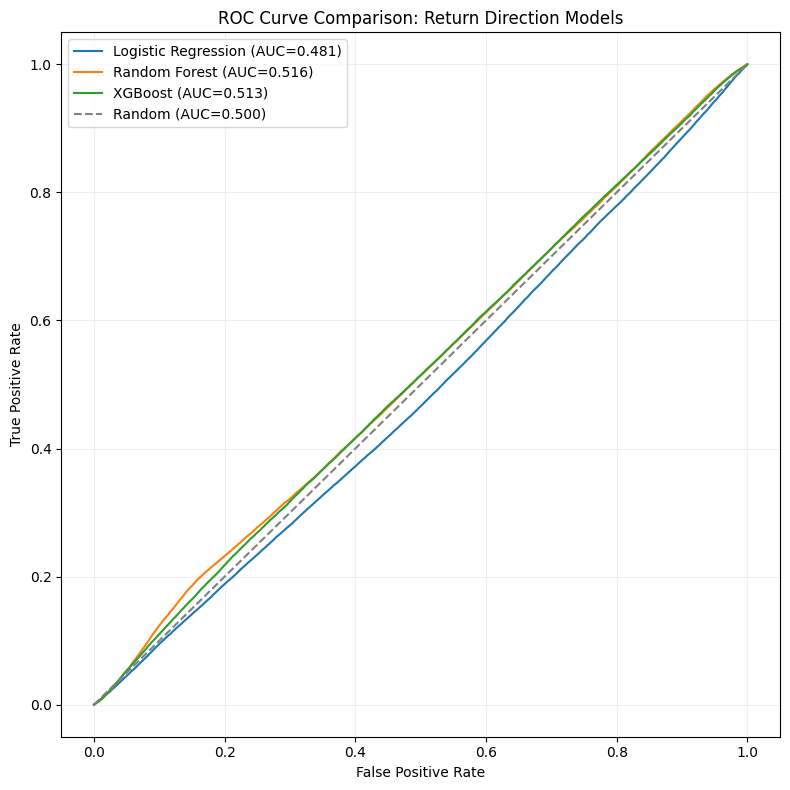

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

for name, proba in [("Logistic Regression", logreg_proba),
                      ("Random Forest", rf_proba),
                      ("XGBoost", xgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test_direction, proba)
    auc = roc_auc_score(y_test_direction, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random (AUC=0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison: Return Direction Models")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "roc_curve_comparison.png"), dpi=150)
plt.show()

In [ ]:
print("Random Forest prediction distribution:")
print(pd.Series(rf_pred).value_counts(normalize=True))
print("\nXGBoost prediction distribution:")
print(pd.Series(xgb_pred).value_counts(normalize=True))
print("\nLogistic Regression prediction distribution:")
print(pd.Series(logreg_pred).value_counts(normalize=True))

Random Forest prediction distribution:
1.0    0.858549
0.0    0.141451
Name: proportion, dtype: float64

XGBoost prediction distribution:
1    0.680267
0    0.319733
Name: proportion, dtype: float64

Logistic Regression prediction distribution:
1.0    0.66384
0.0    0.33616
Name: proportion, dtype: float64


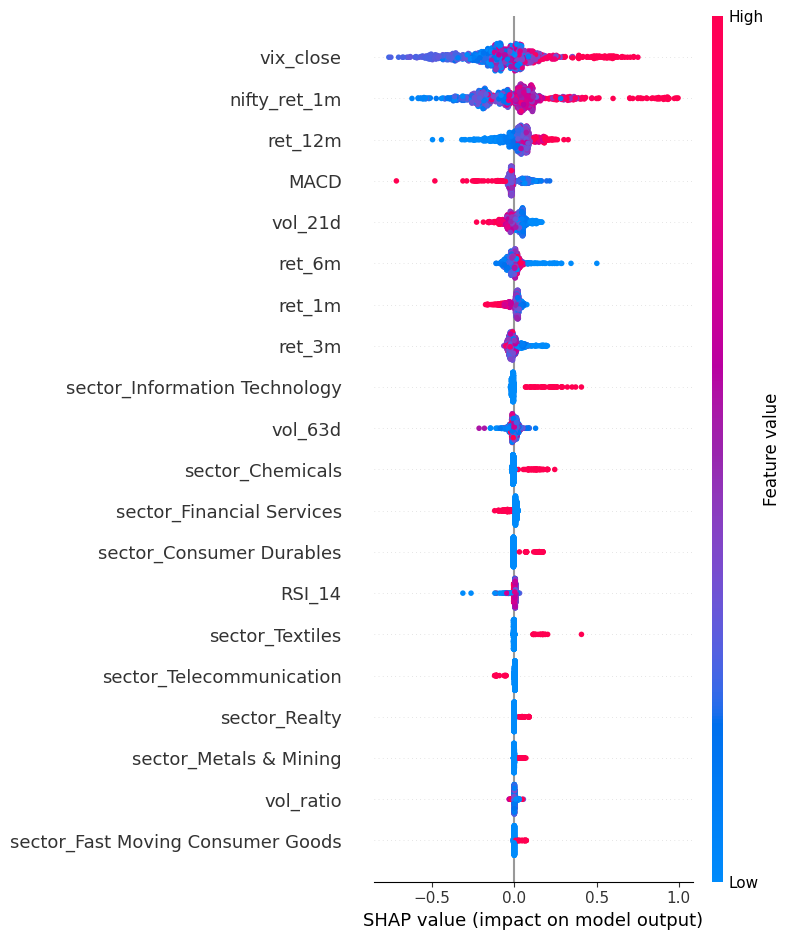

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_model)

X_test_sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "shap_summary_return_direction.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
train_vol = train.dropna(subset=["target_vol"])
test_vol = test.dropna(subset=["target_vol"])

X_train_vol = train_vol[feature_cols]
y_train_vol = train_vol["target_vol"]
X_test_vol = test_vol[feature_cols]
y_test_vol = test_vol["target_vol"]

print(f"Train: {len(train_vol)} rows, Test: {len(test_vol)} rows")

naive_pred = test_vol["vol_21d"].values

print(f"Naive benchmark uses today's vol_21d as tomorrow's predicted vol")
print(f"Sample naive predictions vs actual targets:")
pd.DataFrame({"naive_pred": naive_pred[:5], "actual": y_test_vol.values[:5]})

Train: 582606 rows, Test: 297742 rows
Naive benchmark uses today's vol_21d as tomorrow's predicted vol
Sample naive predictions vs actual targets:


,naive_pred,actual
0,44.182346,36.260753
1,28.198553,21.363009
2,12.757324,6.569683
3,36.309719,39.489087
4,22.594477,37.511927


In [ ]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X_train_vol, y_train_vol)
linreg_pred = linreg.predict(X_test_vol)

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

tscv = TimeSeriesSplit(n_splits=5)

xgb_reg_base = XGBRegressor(random_state=42, n_jobs=-1)

param_grid_reg = {
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [100, 200]
}

xgb_reg_search = GridSearchCV(xgb_reg_base, param_grid_reg, cv=tscv, scoring="neg_root_mean_squared_error", n_jobs=-1)
xgb_reg_search.fit(X_train_vol, y_train_vol)

print(f"Best params: {xgb_reg_search.best_params_}")
xgb_vol_model = xgb_reg_search.best_estimator_
xgb_vol_pred = xgb_vol_model.predict(X_test_vol)

Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

vol_results = {}
predictions = {
    "Naive (today's vol)": naive_pred,
    "Linear Regression": linreg_pred,
    "XGBoost": xgb_vol_pred
}

for name, pred in predictions.items():
    vol_results[name] = {
        "RMSE": np.sqrt(mean_squared_error(y_test_vol, pred)),
        "MAE": mean_absolute_error(y_test_vol, pred),
        "R2": r2_score(y_test_vol, pred)
    }

vol_results_df = pd.DataFrame(vol_results).T.round(3)
vol_results_df

,RMSE,MAE,R2
Naive (today's vol),15.974,11.359,-0.106
Linear Regression,13.091,9.574,0.257
XGBoost,12.786,9.281,0.292


In [ ]:
mz_results = {}
for name, pred in predictions.items():
    mz_model = LinearRegression()
    mz_model.fit(pred.reshape(-1, 1), y_test_vol)
    mz_results[name] = {"intercept": mz_model.intercept_, "slope": mz_model.coef_[0]}

mz_df = pd.DataFrame(mz_results).T.round(3)
print("Mincer-Zarnowitz regression (actual = a + b * predicted; perfect forecast: a=0, b=1)")
mz_df

Mincer-Zarnowitz regression (actual = a + b * predicted; perfect forecast: a=0, b=1)


,intercept,slope
Naive (today's vol),18.940,0.447
Linear Regression,0.541,0.960
XGBoost,-2.420,1.055


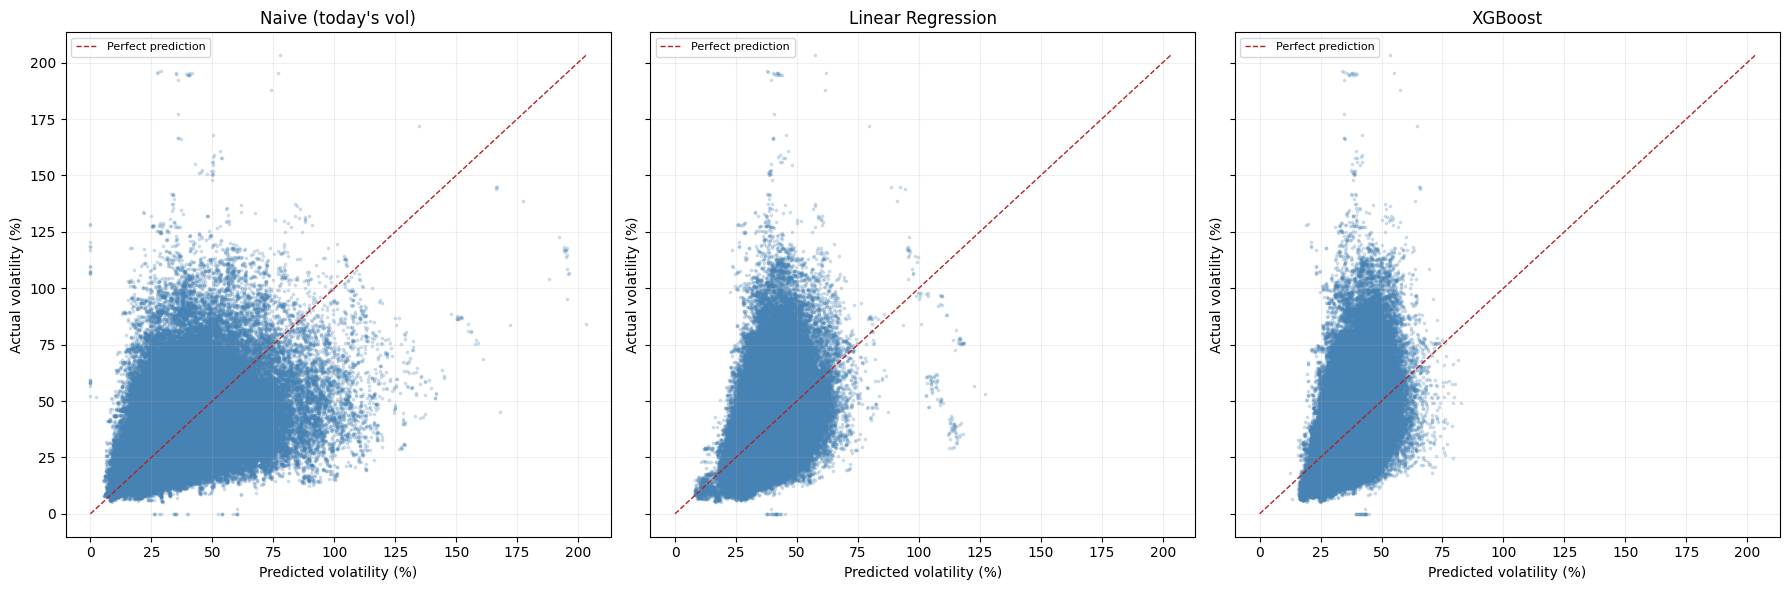

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

for ax, (name, pred) in zip(axes, predictions.items()):
    ax.scatter(pred, y_test_vol, s=3, alpha=0.2, color="steelblue")
    lims = [0, max(y_test_vol.max(), pred.max())]
    ax.plot(lims, lims, color="firebrick", linewidth=1, linestyle="--", label="Perfect prediction")
    ax.set_title(name)
    ax.set_xlabel("Predicted volatility (%)")
    ax.set_ylabel("Actual volatility (%)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "vol_predicted_vs_actual_scatter.png"), dpi=150)
plt.show()

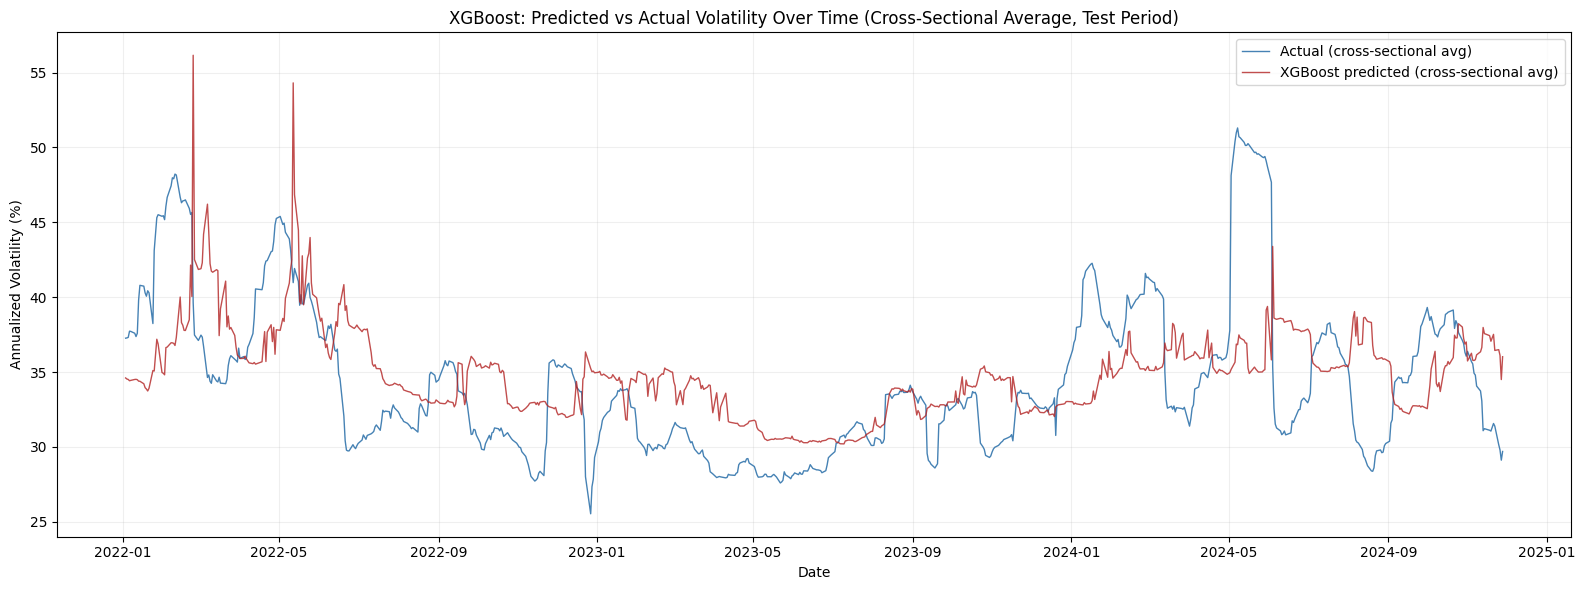

In [ ]:
xgb_vol_results = test_vol[["date"]].copy()
xgb_vol_results["actual"] = y_test_vol.values
xgb_vol_results["predicted"] = xgb_vol_pred

xgb_vol_ts = xgb_vol_results.groupby("date")[["actual", "predicted"]].mean().reset_index()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(xgb_vol_ts["date"], xgb_vol_ts["actual"], color="steelblue", label="Actual (cross-sectional avg)", linewidth=1)
ax.plot(xgb_vol_ts["date"], xgb_vol_ts["predicted"], color="firebrick", label="XGBoost predicted (cross-sectional avg)", linewidth=1, alpha=0.8)
ax.set_title("XGBoost: Predicted vs Actual Volatility Over Time (Cross-Sectional Average, Test Period)")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility (%)")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "vol_predicted_vs_actual_timeseries.png"), dpi=150)
plt.show()

In [ ]:
portfolio_stocks = pd.read_sql("""
    SELECT ticker, ROUND(AVG(close * volume), 0) AS avg_daily_turnover, COUNT(*) AS days
    FROM daily_prices
    WHERE ticker != 'NIFTY_50'
    GROUP BY ticker
    HAVING days > 2600
    ORDER BY avg_daily_turnover DESC
    LIMIT 10
""", conn)

print(portfolio_stocks)
portfolio_stocks_list = portfolio_stocks["ticker"].tolist()

       ticker  avg_daily_turnover  days
0    RELIANCE        1.239189e+10  2710
1    HDFCBANK        1.073919e+10  2710
2   ICICIBANK        9.161196e+09  2710
3        SBIN        8.275055e+09  2710
4        INFY        7.303291e+09  2710
5    AXISBANK        7.062330e+09  2710
6        TMPV        6.758763e+09  2710
7  BAJFINANCE        6.186235e+09  2710
8         TCS        6.017796e+09  2710
9   TATASTEEL        5.557931e+09  2710


In [ ]:
opt_data = df_clean[df_clean["ticker"].isin(portfolio_stocks_list)][["ticker", "date", "adj_close"]].copy()
opt_returns_wide = opt_data.pivot(index="date", columns="ticker", values="adj_close").pct_change().dropna()

mu = opt_returns_wide.mean().values
cov = opt_returns_wide.cov().values

print(f"Universe: {portfolio_stocks_list}")
print(f"Trading days available: {len(opt_returns_wide)}")
print(f"Annualized mean returns:\n{(opt_returns_wide.mean() * 252 * 100).round(2)}")

Universe: ['RELIANCE', 'HDFCBANK', 'ICICIBANK', 'SBIN', 'INFY', 'AXISBANK', 'TMPV', 'BAJFINANCE', 'TCS', 'TATASTEEL']
Trading days available: 2709
Annualized mean returns:
ticker
AXISBANK      19.18
BAJFINANCE    42.06
HDFCBANK      18.92
ICICIBANK     23.27
INFY          19.96
RELIANCE      21.03
SBIN          20.53
TATASTEEL     20.65
TCS           17.55
TMPV          14.77
dtype: float64


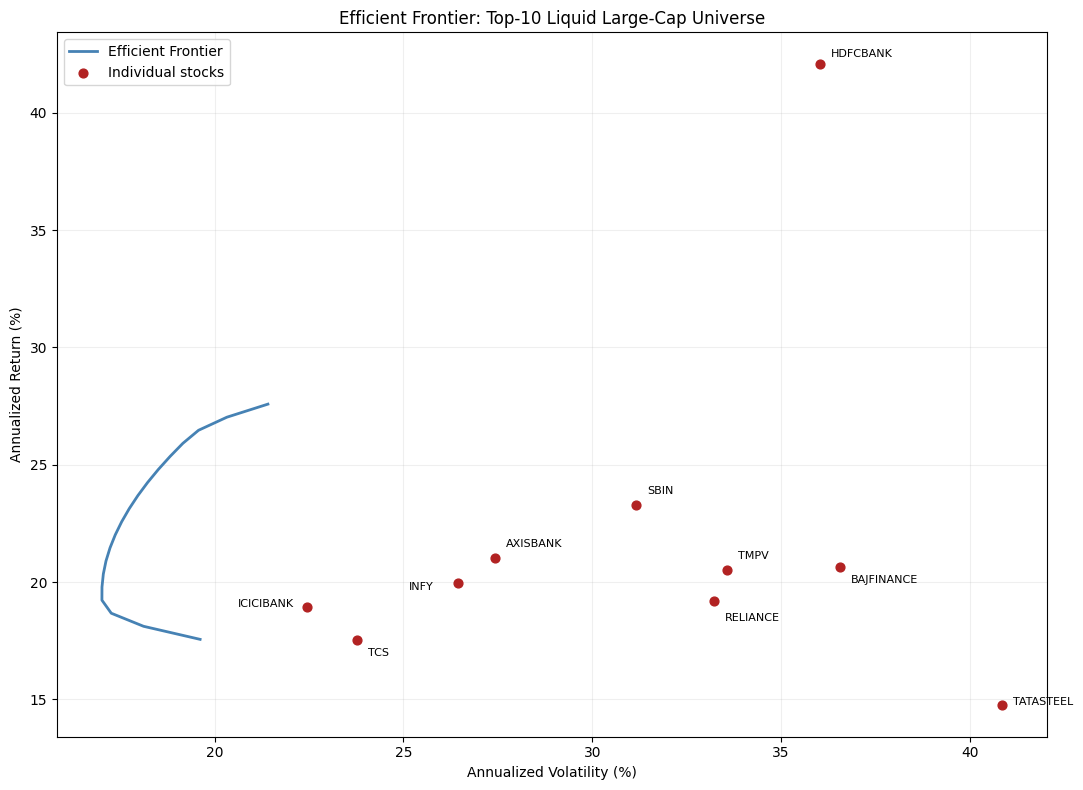

In [ ]:
fig, ax = plt.subplots(figsize=(11, 8))
ax.plot(frontier_df["vol"] * 100, frontier_df["target_return"] * 100, color="steelblue", linewidth=2, label="Efficient Frontier")

individual_vols = np.sqrt(np.diag(cov)) * np.sqrt(252) * 100
individual_rets = mu * 252 * 100
ax.scatter(individual_vols, individual_rets, color="firebrick", s=40, zorder=5, label="Individual stocks")

offsets = {
    "BAJFINANCE": (8, -12), "TMPV": (8, 8), "RELIANCE": (8, -14),
    "SBIN": (8, 8), "AXISBANK": (8, 8), "INFY": (-35, -5),
    "ICICIBANK": (-50, 0), "TCS": (8, -12), "TATASTEEL": (8, 0), "HDFCBANK": (8, 5)
}

for i, ticker in enumerate(portfolio_stocks_list):
    dx, dy = offsets.get(ticker, (8, 8))
    ax.annotate(ticker, (individual_vols[i], individual_rets[i]), fontsize=8,
                xytext=(dx, dy), textcoords="offset points")

ax.set_xlabel("Annualized Volatility (%)")
ax.set_ylabel("Annualized Return (%)")
ax.set_title("Efficient Frontier: Top-10 Liquid Large-Cap Universe")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "efficient_frontier.png"), dpi=150)
plt.show()

In [ ]:
backtest_returns_wide = opt_returns_wide.copy()
backtest_period = backtest_returns_wide[backtest_returns_wide.index >= "2022-01-01"]

rebalance_dates = backtest_period.resample("M").last().index
rebalance_dates = [d for d in rebalance_dates if d in backtest_period.index or True]

print(f"Backtest period: {backtest_period.index.min().date()} to {backtest_period.index.max().date()}")
print(f"Number of months: {len(rebalance_dates)}")

Backtest period: 2022-01-03 to 2024-12-30
Number of months: 36


/tmp/ipykernel_913/3881799849.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rebalance_dates = backtest_period.resample("M").last().index


In [ ]:
def compute_weights(returns_lookback, strategy, n_assets):
    mu_lb = returns_lookback.mean().values
    cov_lb = returns_lookback.cov().values
    bounds = tuple((0, 0.3) for _ in range(n_assets))
    constraints = ({"type": "eq", "fun": lambda w: np.sum(w) - 1},)

    if strategy == "equal_weight":
        return np.ones(n_assets) / n_assets

    elif strategy == "min_variance":
        result = minimize(portfolio_vol, x0=np.ones(n_assets)/n_assets, args=(mu_lb, cov_lb),
                           method="SLSQP", bounds=bounds, constraints=constraints)
        return result.x if result.success else np.ones(n_assets) / n_assets

    elif strategy == "max_sharpe":
        result = minimize(neg_sharpe, x0=np.ones(n_assets)/n_assets, args=(mu_lb, cov_lb),
                           method="SLSQP", bounds=bounds, constraints=constraints)
        return result.x if result.success else np.ones(n_assets) / n_assets

In [ ]:
strategies = ["equal_weight", "min_variance", "max_sharpe"]
strategy_returns = {s: [] for s in strategies}
strategy_dates = []

lookback_window = 252

all_dates = backtest_returns_wide.index
backtest_start_idx = all_dates.get_indexer([pd.Timestamp("2022-01-01")], method="bfill")[0]

current_month = None
weights_cache = {}

for i in range(backtest_start_idx, len(all_dates)):
    date = all_dates[i]
    month = date.to_period("M")

    if month != current_month:
        lookback_data = backtest_returns_wide.iloc[max(0, i - lookback_window):i]
        for s in strategies:
            weights_cache[s] = compute_weights(lookback_data, s, n)
        current_month = month

    day_returns = backtest_returns_wide.iloc[i].values
    for s in strategies:
        port_ret = np.dot(weights_cache[s], day_returns)
        strategy_returns[s].append(port_ret)

    strategy_dates.append(date)

backtest_df = pd.DataFrame(strategy_returns, index=strategy_dates)
print(f"Backtest days: {len(backtest_df)}")
backtest_df.head()

Backtest days: 738


,equal_weight,min_variance,max_sharpe
2022-01-03,0.024520,0.018437,0.020077
2022-01-04,0.010893,0.011204,0.004632
2022-01-05,0.012672,-0.000479,-0.003076
2022-01-06,-0.007043,-0.013653,-0.008444
2022-01-07,0.002481,0.005437,0.001626


In [ ]:
nifty_backtest = df_clean[(df_clean["ticker"] == "NIFTY_50") & (df_clean["date"] >= "2022-01-01")][["date", "log_return"]].copy()
nifty_backtest = nifty_backtest.set_index("date")
nifty_backtest["nifty_simple_return"] = np.exp(nifty_backtest["log_return"]) - 1

backtest_df = backtest_df.merge(nifty_backtest[["nifty_simple_return"]], left_index=True, right_index=True, how="inner")
backtest_df = backtest_df.rename(columns={"nifty_simple_return": "nifty_50"})

cumulative_returns = (1 + backtest_df).cumprod()

print(f"Final cumulative returns:")
print(cumulative_returns.iloc[-1])

Final cumulative returns:
equal_weight    1.419965
min_variance    1.329684
max_sharpe      1.307943
nifty_50        1.362500
Name: 2024-12-30 00:00:00, dtype: float64


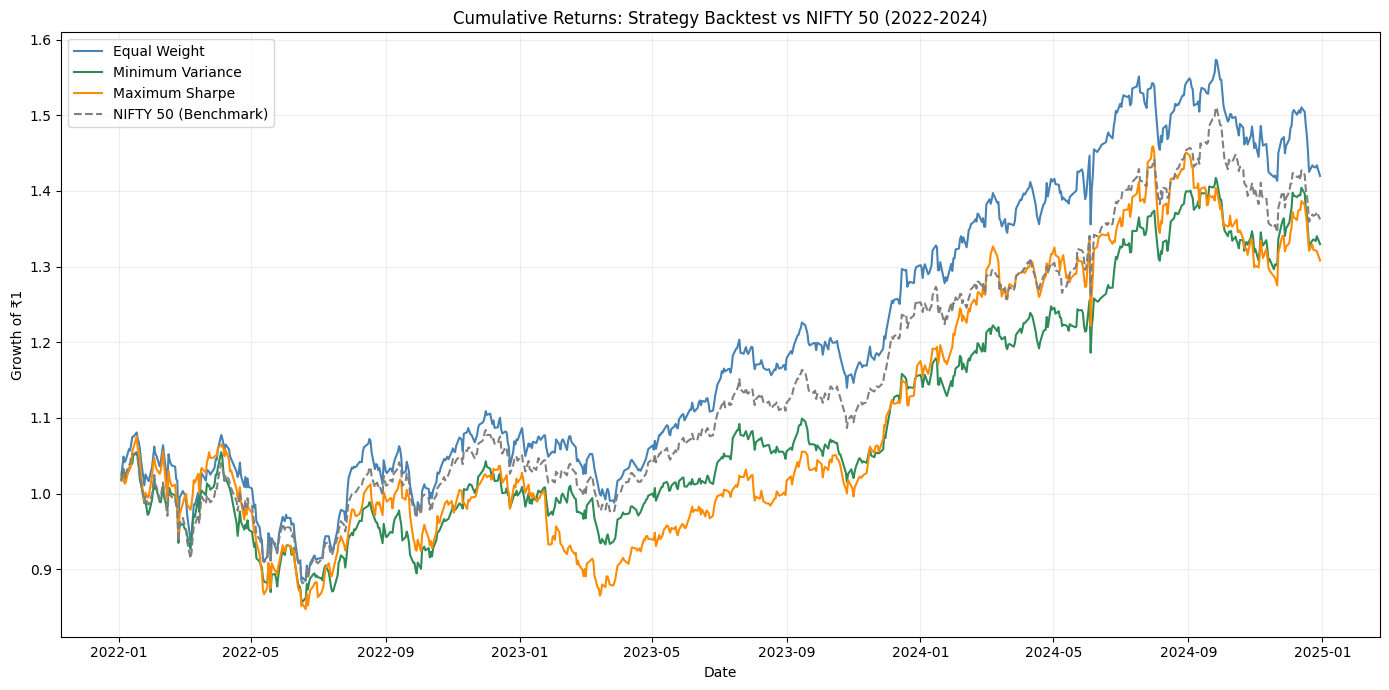

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

labels = {"equal_weight": "Equal Weight", "min_variance": "Minimum Variance",
          "max_sharpe": "Maximum Sharpe", "nifty_50": "NIFTY 50 (Benchmark)"}
colors = {"equal_weight": "steelblue", "min_variance": "seagreen",
          "max_sharpe": "darkorange", "nifty_50": "gray"}

for col in cumulative_returns.columns:
    style = "--" if col == "nifty_50" else "-"
    ax.plot(cumulative_returns.index, cumulative_returns[col], label=labels[col],
            color=colors[col], linestyle=style, linewidth=1.5)

ax.set_title("Cumulative Returns: Strategy Backtest vs NIFTY 50 (2022-2024)")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of ₹1")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "strategy_backtest_cumulative.png"), dpi=150)
plt.show()

In [ ]:
high_vol_period = cumulative_returns[(cumulative_returns.index >= "2022-01-01") & (cumulative_returns.index <= "2022-07-01")]
bull_period = cumulative_returns[(cumulative_returns.index >= "2023-09-01") & (cumulative_returns.index <= "2024-09-01")]

print("High-vol period (Jan-Jul 2022) relative performance:")
print((high_vol_period.iloc[-1] / high_vol_period.iloc[0] - 1) * 100)

print("\nBull run period (Sep 2023-Sep 2024) relative performance:")
print((bull_period.iloc[-1] / bull_period.iloc[0] - 1) * 100)

High-vol period (Jan-Jul 2022) relative performance:
equal_weight   -10.803685
min_variance   -12.676255
max_sharpe     -15.390230
nifty_50       -10.630213
dtype: float64

Bull run period (Sep 2023-Sep 2024) relative performance:
equal_weight    30.866345
min_variance    32.573225
max_sharpe      42.634401
nifty_50        29.845690
dtype: float64


In [ ]:
def compute_performance_stats(returns_series, rf=0.06):
    ann_return = returns_series.mean() * 252
    ann_vol = returns_series.std() * np.sqrt(252)
    sharpe = (ann_return - rf) / ann_vol

    cum = (1 + returns_series).cumprod()
    running_peak = cum.cummax()
    drawdown = (cum / running_peak - 1)
    max_dd = drawdown.min()

    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return pd.Series({
        "Annualized Return (%)": ann_return * 100,
        "Annualized Vol (%)": ann_vol * 100,
        "Sharpe Ratio": sharpe,
        "Max Drawdown (%)": max_dd * 100,
        "Calmar Ratio": calmar
    })

performance_table = backtest_df.apply(compute_performance_stats).T
performance_table.index = ["Equal Weight", "Minimum Variance", "Maximum Sharpe", "NIFTY 50"]
performance_table.round(2)

,Annualized Return (%),Annualized Vol (%),Sharpe Ratio,Max Drawdown (%),Calmar Ratio
Equal Weight,13.32,16.38,0.45,-18.15,0.73
Minimum Variance,10.93,15.50,0.32,-18.74,0.58
Maximum Sharpe,10.85,18.31,0.27,-21.28,0.51
NIFTY 50,11.56,14.09,0.39,-16.47,0.70
